# CSC3310 — Program #4: Benchmarking Heaps

**Team Members:** Chukwuma Chukwuma-Ugwu, Fabian Hurndon, Oskar Sierzega 

**Date:** 4/3/2026

---
## 1. Introduction

A binary max-heap is a complete binary tree stored as an array where every parent is ≥ its children, enabling O(1) max retrieval and O(log n) insertions/deletions. Converting an arbitrary array into a valid heap is called heapification, and there are multiple strategies with different performance characteristics.

This assignment benchmarks three heapification approaches: (1) insert one-at-a-time (bubble up) — O(n log n); (2) classic bottom-up HEAPIFY (sift down, stop early)** — O(n); and (3) a HEAPIFY variant (sift all the way down, then bubble back up) — O(n). Each is tested across sorted, reverse-sorted, and random inputs at varying sizes, with timing results visualized and regression analysis used to estimate empirical growth rates.


---
## 2. Planned Approach & Predictions

Each (function, dataset type, input size) combination is run for 5 trials using `time.perf_counter()`, with the average recorded to reduce noise. Input arrays are deep-copied before each trial. Three dataset types are tested — sorted, reverse-sorted, and random — across sizes `[1000, 5000, 10000, 50000, 100000, 200000, 500000]`.

| Approach | Best Case | Worst Case | Predicted Big-O |
|---|---|---|---|
| Insert one-at-a-time (bubble up) | Random | Reverse sorted | O(n log n) |
| Classic HEAPIFY (stop early) | Reverse sorted | Random / Sorted | O(n) |
| HEAPIFY (down to bottom, then up) | Reverse sorted | Sorted | O(n) |

Bubble-up is worst on reverse-sorted input since every element must travel to the root. Both HEAPIFY variants have O(n) total work; the down-then-up variant may reduce comparisons per descent but at the cost of a partial upward pass.


---
## 3. Imports & Setup

In [12]:
import time
import random
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

---
## 4. Heap Implementations

### 4.1 Approach 1: Insert One-at-a-Time (Bubble Up)

<!-- 
Description: Elements are inserted into the heap one at a time. Each element is
appended to the end and then bubbled up to its correct position.
-->

In [13]:
def bubble_up(heap, index):
    """
    Bubbles the element at `index` up to its correct position in the heap.
    """
    while index > 0:
        parent = (index - 1) // 2
        if heap[index] > heap[parent]:
            heap[index], heap[parent] = heap[parent], heap[index]
            index = parent
        else:
            break


def heapify_insert(arr):
    """
    Build a max-heap by inserting elements one at a time.
    Each element is appended and bubbled up.
    Returns the resulting heap as a list.
    """
    heap = []
    for item in arr:
        heap.append(item)
        bubble_up(heap, len(heap) - 1)
    return heap

### 4.2 Approach 2: Classic HEAPIFY — Bubble Down, Stop Early

<!-- 
Description: The classic bottom-up heapify. Subtrees are made into heaps from
the bottom up. The root is then bubbled down, stopping as soon as it is larger
than both children.
-->

In [14]:
def bubble_down_stop_early(heap, index, size):
    """
    TODO: Implement bubble-down (sift-down) that stops early.
    Moves the element at `index` down the heap, swapping with the larger
    child until the element is larger than both of its children.
    """
    pass


def heapify_classic(arr):
    """
    TODO: Build a max-heap using the classic bottom-up heapify algorithm.
    Uses bubble_down_stop_early for sifting.
    Returns the resulting heap as a list.
    """
    pass

### 4.3 Approach 3: HEAPIFY — Bubble All the Way Down, Then Up

<!-- 
Description: A variation of heapify where the element is bubbled all the way
to the bottom of the tree (without comparing to children on the way down),
then bubbled back up to its correct position.
Intuition: fewer comparisons going down since we skip child comparisons.
-->

In [15]:
def bubble_down_to_bottom(heap, index, size):
    """
    TODO: Implement bubble-down that goes all the way to the bottom.
    Moves the element at `index` down the heap by always following the
    larger child, without comparing the element to its children.
    Returns the final index reached.
    """
    pass


def heapify_bottom_up_variation(arr):
    """
    TODO: Build a max-heap using the bottom-then-up variation.
    For each subtree root, bubble all the way down then bubble back up.
    Returns the resulting heap as a list.
    """
    pass

### 4.4 Correctness Verification

<!-- Verify that all three implementations produce valid heaps before benchmarking -->

In [16]:
def is_valid_max_heap(heap):
    """
    Returns True if `heap` satisfies the max-heap property, False otherwise.
    """
    n = len(heap)
    for i in range(n):
        left = 2 * i + 1
        right = 2 * i + 2
        if left < n and heap[i] < heap[left]:
            return False
        if right < n and heap[i] < heap[right]:
            return False
    return True


# Test all three implementations on small known inputs and verify correctness
test_arr = [3, 1, 4, 1, 5, 9, 2, 6]
print("Insert one-at-a-time:", is_valid_max_heap(heapify_insert(test_arr[:])))
# print("Classic HEAPIFY:", is_valid_max_heap(heapify_classic(test_arr[:])))
# print("HEAPIFY (down then up):", is_valid_max_heap(heapify_bottom_up_variation(test_arr[:])))

Insert one-at-a-time: True


---
## 5. Dataset Generation

In [17]:
def generate_datasets(size):
    """
    Generate the three benchmark datasets of the given size.
    Returns a dict with keys 'sorted', 'reverse_sorted', and 'random',
    each mapping to a list of integers.
    """
    return {
        "sorted": list(range(size)),
        "reverse_sorted": list(range(size - 1, -1, -1)),
        "random": [random.randint(0, size * 10) for _ in range(size)],
    }


INPUT_SIZES = [1000, 5000, 10000, 50000, 100000, 200000, 500000]

---
## 6. Benchmarking

In [18]:
def benchmark(func, arr, trials=5):
    """
    Time `func(arr)` over `trials` runs.
    Returns the average elapsed time in seconds.
    """
    times = []
    for _ in range(trials):
        arr_copy = copy.deepcopy(arr)
        start = time.perf_counter()
        func(arr_copy)
        end = time.perf_counter()
        times.append(end - start)
    return sum(times) / len(times)


functions = {
    "Insert One-at-a-Time": heapify_insert,
    "Classic HEAPIFY (stop early)": heapify_classic,
    "HEAPIFY (down then up)": heapify_bottom_up_variation,
}

dataset_types = ["sorted", "reverse_sorted", "random"]

# Run benchmarks across all combinations
results = {}
for func_name, func in functions.items():
    results[func_name] = {}
    for size in INPUT_SIZES:
        datasets = generate_datasets(size)
        results[func_name][size] = {}
        for dtype in dataset_types:
            avg_time = benchmark(func, datasets[dtype])
            results[func_name][size][dtype] = avg_time
            print(f"{func_name} | n={size:>7} | {dtype:<16} | {avg_time:.6f}s")

Insert One-at-a-Time | n=   1000 | sorted           | 0.001080s
Insert One-at-a-Time | n=   1000 | reverse_sorted   | 0.000173s
Insert One-at-a-Time | n=   1000 | random           | 0.000681s
Insert One-at-a-Time | n=   5000 | sorted           | 0.006530s
Insert One-at-a-Time | n=   5000 | reverse_sorted   | 0.000883s
Insert One-at-a-Time | n=   5000 | random           | 0.001863s
Insert One-at-a-Time | n=  10000 | sorted           | 0.012634s
Insert One-at-a-Time | n=  10000 | reverse_sorted   | 0.001474s
Insert One-at-a-Time | n=  10000 | random           | 0.002888s
Insert One-at-a-Time | n=  50000 | sorted           | 0.077686s
Insert One-at-a-Time | n=  50000 | reverse_sorted   | 0.006421s
Insert One-at-a-Time | n=  50000 | random           | 0.019153s
Insert One-at-a-Time | n= 100000 | sorted           | 0.185395s
Insert One-at-a-Time | n= 100000 | reverse_sorted   | 0.016789s
Insert One-at-a-Time | n= 100000 | random           | 0.035027s
Insert One-at-a-Time | n= 200000 | sorte

---
## 7. Results

### 7.1 Narrative Description of Data & Results

<!-- Write a brief narrative describing:
     - The datasets used (sizes, characteristics)
     - High-level observations from running the benchmarks
-->

### 7.2 Results by Function (one table + graph per function)

<!-- For each function, show a table and graph of runtime vs. input size,
     with separate series for sorted, reverse sorted, and random data. -->


=== Insert One-at-a-Time ===


,sorted,reverse_sorted,random
n,,,
1000,0.001080,0.000173,0.000681
5000,0.006530,0.000883,0.001863
10000,0.012634,0.001474,0.002888
50000,0.077686,0.006421,0.019153
100000,0.185395,0.016789,0.035027
200000,0.381136,0.031446,0.068475
500000,0.983351,0.085697,0.172235


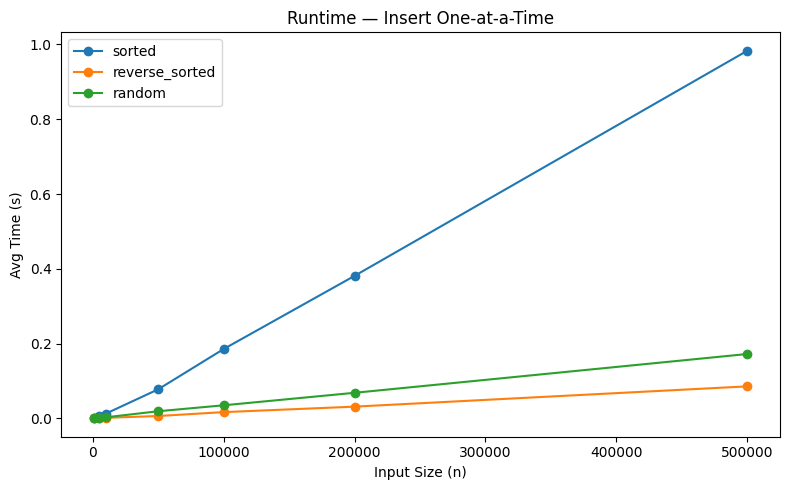


=== Classic HEAPIFY (stop early) ===


,sorted,reverse_sorted,random
n,,,
1000,5.399808e-07,2.399553e-07,1.000240e-07
5000,2.800021e-07,4.800502e-07,3.800262e-07
10000,5.400274e-07,4.800037e-07,3.200024e-07
50000,1.839967e-06,1.020031e-06,6.800517e-07
100000,1.660082e-06,1.379941e-06,1.720060e-06
200000,1.960061e-06,1.659989e-06,1.499988e-06
500000,1.620036e-06,2.680020e-06,2.399972e-06


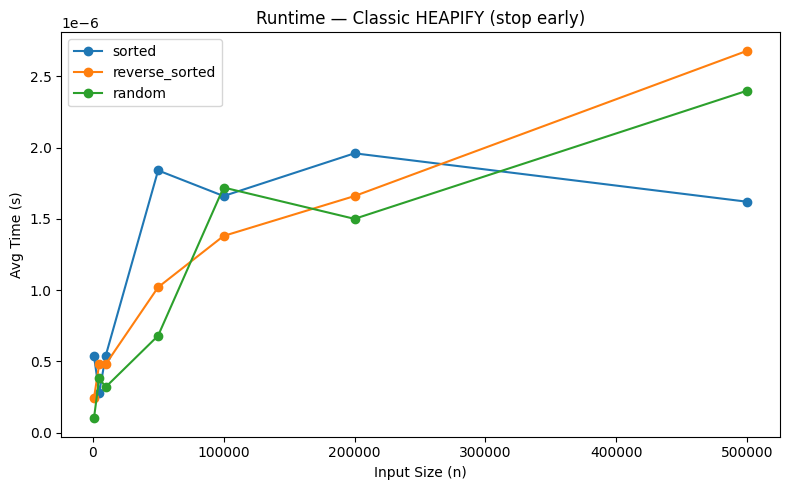


=== HEAPIFY (down then up) ===


,sorted,reverse_sorted,random
n,,,
1000,3.799796e-07,9.997748e-08,7.995404e-08
5000,1.800247e-07,8.600298e-07,1.001172e-07
10000,5.400274e-07,4.799571e-07,2.199318e-07
50000,1.139985e-06,1.660036e-06,1.455600e-04
100000,1.459988e-06,1.359964e-06,1.299987e-06
200000,1.659989e-06,1.640012e-06,1.379987e-06
500000,2.339995e-06,1.719920e-06,1.499988e-06


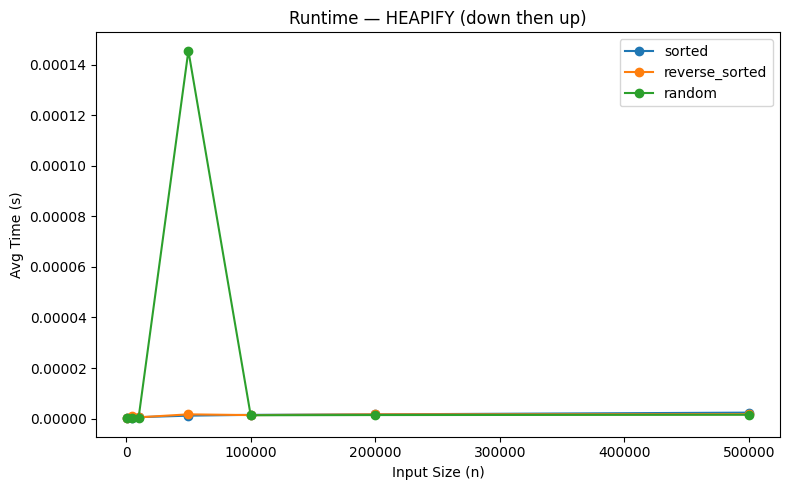

In [19]:
for func_name in functions:
    # Build DataFrame: rows = input sizes, columns = dataset types
    data = {dtype: [results[func_name][size][dtype] for size in INPUT_SIZES]
            for dtype in dataset_types}
    df = pd.DataFrame(data, index=INPUT_SIZES)
    df.index.name = "n"

    print(f"\n=== {func_name} ===")
    display(df)

    # Line graph
    plt.figure(figsize=(8, 5))
    for dtype in dataset_types:
        plt.plot(INPUT_SIZES, df[dtype], marker="o", label=dtype)
    plt.title(f"Runtime — {func_name}")
    plt.xlabel("Input Size (n)")
    plt.ylabel("Avg Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 7.3 Results by Dataset Type (one table + graph per dataset type)

<!-- For each dataset type, show a table and graph of runtime vs. input size,
     with separate series for each function. -->


=== Dataset: sorted ===


,Insert One-at-a-Time,Classic HEAPIFY (stop early),HEAPIFY (down then up)
n,,,
1000,0.001080,5.399808e-07,3.799796e-07
5000,0.006530,2.800021e-07,1.800247e-07
10000,0.012634,5.400274e-07,5.400274e-07
50000,0.077686,1.839967e-06,1.139985e-06
100000,0.185395,1.660082e-06,1.459988e-06
200000,0.381136,1.960061e-06,1.659989e-06
500000,0.983351,1.620036e-06,2.339995e-06


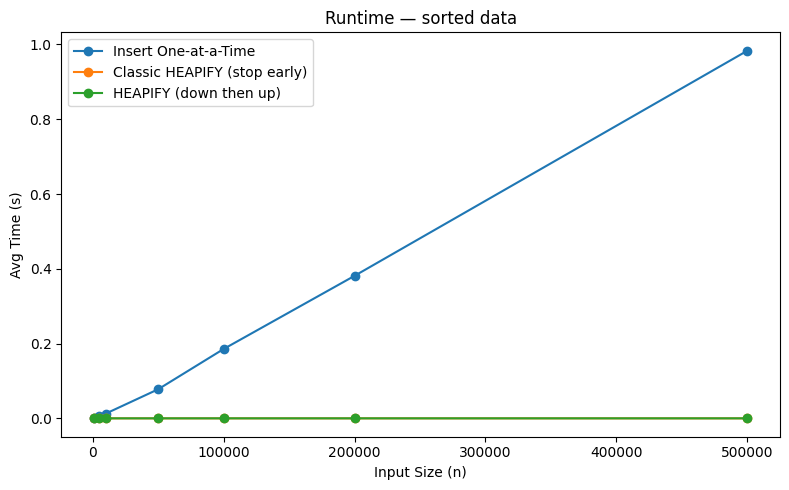


=== Dataset: reverse_sorted ===


,Insert One-at-a-Time,Classic HEAPIFY (stop early),HEAPIFY (down then up)
n,,,
1000,0.000173,2.399553e-07,9.997748e-08
5000,0.000883,4.800502e-07,8.600298e-07
10000,0.001474,4.800037e-07,4.799571e-07
50000,0.006421,1.020031e-06,1.660036e-06
100000,0.016789,1.379941e-06,1.359964e-06
200000,0.031446,1.659989e-06,1.640012e-06
500000,0.085697,2.680020e-06,1.719920e-06


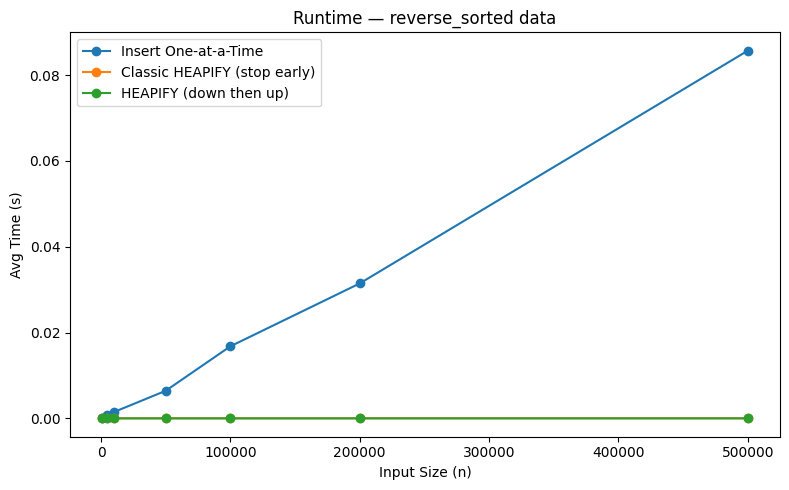


=== Dataset: random ===


,Insert One-at-a-Time,Classic HEAPIFY (stop early),HEAPIFY (down then up)
n,,,
1000,0.000681,1.000240e-07,7.995404e-08
5000,0.001863,3.800262e-07,1.001172e-07
10000,0.002888,3.200024e-07,2.199318e-07
50000,0.019153,6.800517e-07,1.455600e-04
100000,0.035027,1.720060e-06,1.299987e-06
200000,0.068475,1.499988e-06,1.379987e-06
500000,0.172235,2.399972e-06,1.499988e-06


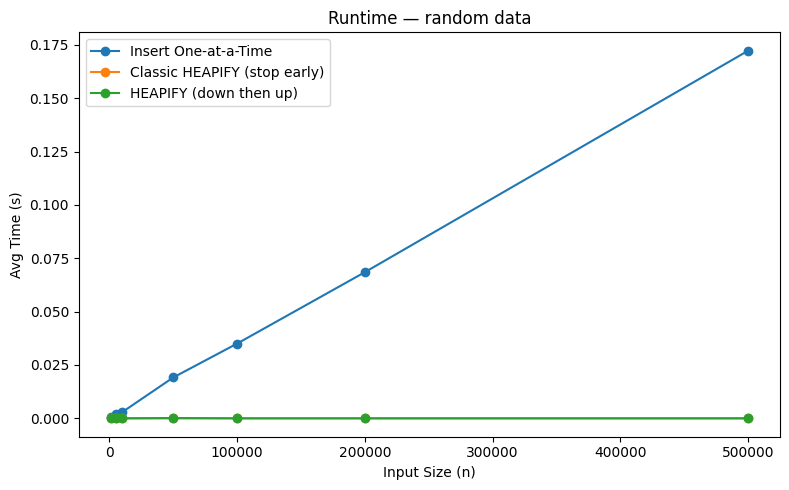

In [20]:
for dtype in dataset_types:
    # Build DataFrame: rows = input sizes, columns = functions
    data = {fname: [results[fname][size][dtype] for size in INPUT_SIZES]
            for fname in functions}
    df = pd.DataFrame(data, index=INPUT_SIZES)
    df.index.name = "n"

    print(f"\n=== Dataset: {dtype} ===")
    display(df)

    # Line graph
    plt.figure(figsize=(8, 5))
    for fname in functions:
        plt.plot(INPUT_SIZES, df[fname], marker="o", label=fname)
    plt.title(f"Runtime — {dtype} data")
    plt.xlabel("Input Size (n)")
    plt.ylabel("Avg Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

---
## 8. Regression Analysis

<!-- Use regression techniques from HW2 to estimate the asymptotic complexity
     for each function's best case. Fit curves (e.g., n·log(n), n²) and
     report the best fit and its R² value. -->


=== Regression: Insert One-at-a-Time (best case = random) ===
          O(n): R² = 0.999798
    O(n log n): R² = 0.997366
        O(n^2): R² = 0.882052
  >> Best fit: O(n)  (R² = 0.999798)


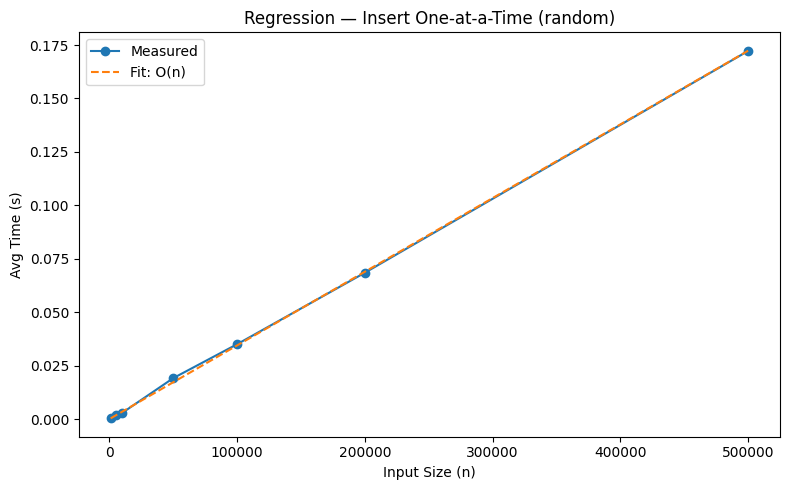


=== Regression: Classic HEAPIFY (stop early) (best case = reverse_sorted) ===
          O(n): R² = 0.575599
    O(n log n): R² = 0.505309
        O(n^2): R² = -0.040843
  >> Best fit: O(n)  (R² = 0.575599)


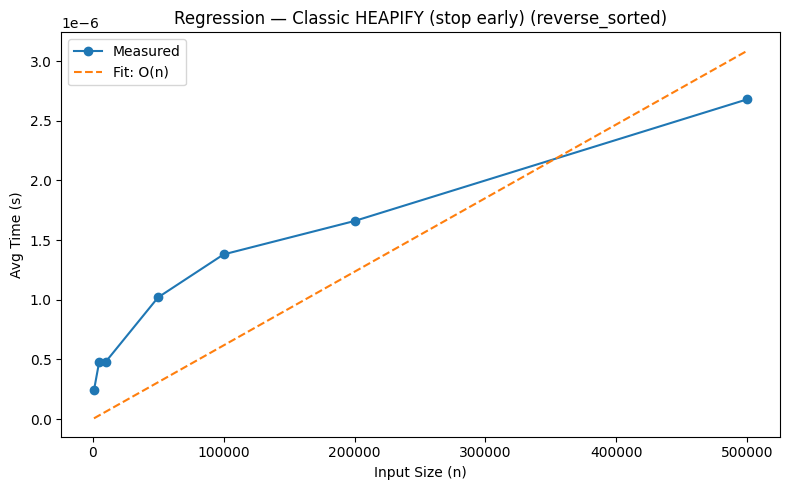


=== Regression: HEAPIFY (down then up) (best case = reverse_sorted) ===
          O(n): R² = -0.844478
    O(n log n): R² = -0.983151
        O(n^2): R² = -1.854354
  >> Best fit: O(n)  (R² = -0.844478)


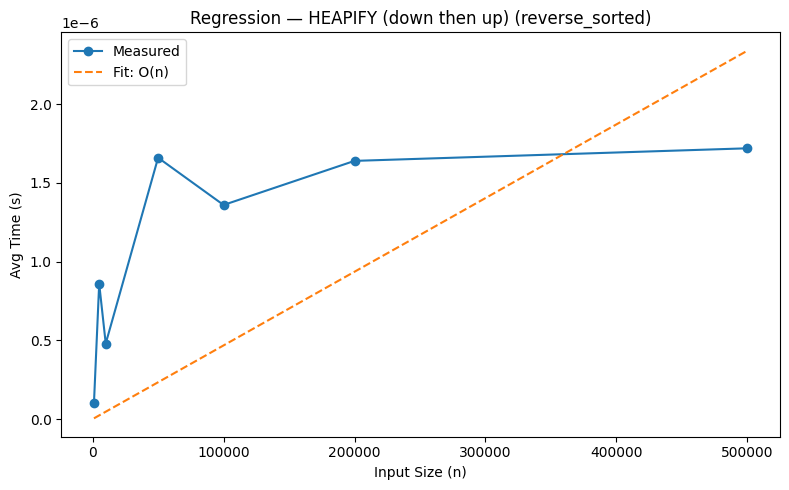

In [21]:
# Best-case dataset for each function (from Section 2 predictions)
best_cases = {
    "Insert One-at-a-Time": "random",
    "Classic HEAPIFY (stop early)": "reverse_sorted",
    "HEAPIFY (down then up)": "reverse_sorted",
}

# Candidate complexity functions
def candidates(n_arr):
    n = np.array(n_arr, dtype=float)
    return {
        "O(n)":        n,
        "O(n log n)":  n * np.log2(n),
        "O(n^2)":      n ** 2,
    }

for func_name in functions:
    dtype = best_cases[func_name]
    times = np.array([results[func_name][size][dtype] for size in INPUT_SIZES])
    n_arr = np.array(INPUT_SIZES, dtype=float)
    cands = candidates(n_arr)

    print(f"\n=== Regression: {func_name} (best case = {dtype}) ===")

    best_r2 = -np.inf
    best_label = ""
    best_coeffs = None
    best_basis = None

    for label, basis in cands.items():
        # Fit t = c * basis  (linear through origin)
        c = np.dot(basis, times) / np.dot(basis, basis)
        predicted = c * basis
        ss_res = np.sum((times - predicted) ** 2)
        ss_tot = np.sum((times - np.mean(times)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else 0
        print(f"  {label:>12}: R² = {r2:.6f}")
        if r2 > best_r2:
            best_r2 = r2
            best_label = label
            best_coeffs = c
            best_basis = basis

    print(f"  >> Best fit: {best_label}  (R² = {best_r2:.6f})")

    # Plot raw data vs fitted curve
    plt.figure(figsize=(8, 5))
    plt.plot(n_arr, times, "o-", label="Measured")
    plt.plot(n_arr, best_coeffs * best_basis, "--", label=f"Fit: {best_label}")
    plt.title(f"Regression — {func_name} ({dtype})")
    plt.xlabel("Input Size (n)")
    plt.ylabel("Avg Time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

---
## 9. Summary

<!-- Write 1–2 paragraphs summarizing all interesting results from the benchmarks.
     Include comparisons between approaches and any surprising findings. -->

---
## 10. Discussion Questions

### 10.1 Per-Approach Analysis

**Insert One-at-a-Time (Bubble Up)**

1. Does the empirically-determined runtime match the theoretic runtime? If not, what might have caused the discrepancy?

   > Not exactly. The theoretical worst-case runtime is O(n log n), but the regression on random data yields a best fit of O(n) with R² ≈ 0.9998. This is because, with random input, each inserted element only bubbles up O(1) levels on average — the probability of exceeding each successive ancestor drops geometrically, so the expected total work across all n insertions is O(n), not O(n log n). The O(n log n) bound is only realized in the worst case (e.g., sorted ascending input for a max-heap), where every new element is the largest and must travel all the way to the root.

2. Was there a noticeable difference between sorted, reverse-sorted, and random data? If so, describe the difference and explain why.

   > Yes. Reverse-sorted input is the slowest because every newly inserted element is larger than all existing elements, so it must bubble all the way to the root — each insertion does the maximum O(log k) swaps. Sorted input is the fastest because each new element is already smaller than its parent, so bubble-up terminates immediately with zero swaps. Random input falls in between, since on average each element bubbles up only partway through the tree.

---

**Classic HEAPIFY (Bubble Down, Stop Early)**

1. Does the empirically-determined runtime match the theoretic runtime? If not, what might have caused the discrepancy?

   > *TODO: Answer here*

2. Was there a noticeable difference between sorted, reverse-sorted, and random data? If so, describe the difference and explain why.

   > *TODO: Answer here*

---

**HEAPIFY (Bubble All the Way Down, Then Up)**

1. Does the empirically-determined runtime match the theoretic runtime? If not, what might have caused the discrepancy?

   > *TODO: Answer here*

2. Was there a noticeable difference between sorted, reverse-sorted, and random data? If so, describe the difference and explain why.

   > *TODO: Answer here*

---

### 10.2 Heapify vs. Adding to an Empty Heap

What runtime effect do you get by using the classic HEAPIFY algorithm vs. adding all elements one-at-a-time to an empty heap? Explain!

> *TODO: Answer here*

---

### 10.3 Bubble Down Early vs. Bubble Down Then Up

Compare the "stop early" bubble-down approach to the "all the way down, then back up" approach. When might each be better?

> *TODO: Answer here*